## 1. Importing Needed Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
warnings.filterwarnings('ignore')

## 2. Loading Data

In [2]:
df = pd.read_csv('data/CC_GENERAL.csv')

## 3. Data Overview

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()
print(f"{'_'*50}\n")
print(f'Number of Duplicates: {df.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [6]:
print(f'Number of Missing data:{df.isna().sum()}')

Number of Missing data:CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


## 4. Organizing Data

In [7]:
# Dropping customer id since it is not needed
df = df.drop('CUST_ID', axis = 1)

# Fill missing values
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df)

df_cleaned = pd.DataFrame(df_imputed, columns=df.columns)
print(f'Missing values now:\n\n{df_cleaned.isna().sum()}')

Missing values now:

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [8]:
log_features = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 
    'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 
    'CASH_ADVANCE_TRX', 'PURCHASES_TRX'
] # Fixes right-skewness and squashes high variance.

for col in log_features:
    if col in df_cleaned.columns:
        df_cleaned[col] = np.log1p(df_cleaned[col])

In [9]:
df_cleaned.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,6.161637,0.877271,4.899647,3.204274,3.352403,3.319086,0.490351,0.202458,0.364437,0.135144,0.817570,1.894731,8.094784,6.624540,5.899242,0.153715,11.517318
std,2.013303,0.236904,2.916872,3.246365,3.082973,3.566298,0.401371,0.298336,0.397448,0.200121,1.009316,1.373856,0.819643,1.591763,1.194852,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.931826,0.000000,0.018982,0.000000,6.000000
25%,4.861995,0.888889,3.704627,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.693147,7.378384,5.951361,5.119854,0.000000,12.000000
50%,6.773521,1.000000,5.892417,3.663562,4.499810,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,2.079442,8.006701,6.754489,5.710282,0.000000,12.000000
75%,7.628099,1.000000,7.013133,6.360274,6.151961,7.016449,0.916667,0.300000,0.750000,0.222222,1.609438,2.890372,8.779711,7.550732,6.691357,0.142857,12.000000
max,9.854515,1.000000,10.800403,10.615512,10.021315,10.760839,1.000000,1.000000,1.000000,1.500000,4.820282,5.883322,10.308986,10.834125,11.243832,1.000000,12.000000


## 5. Visualizing the Data

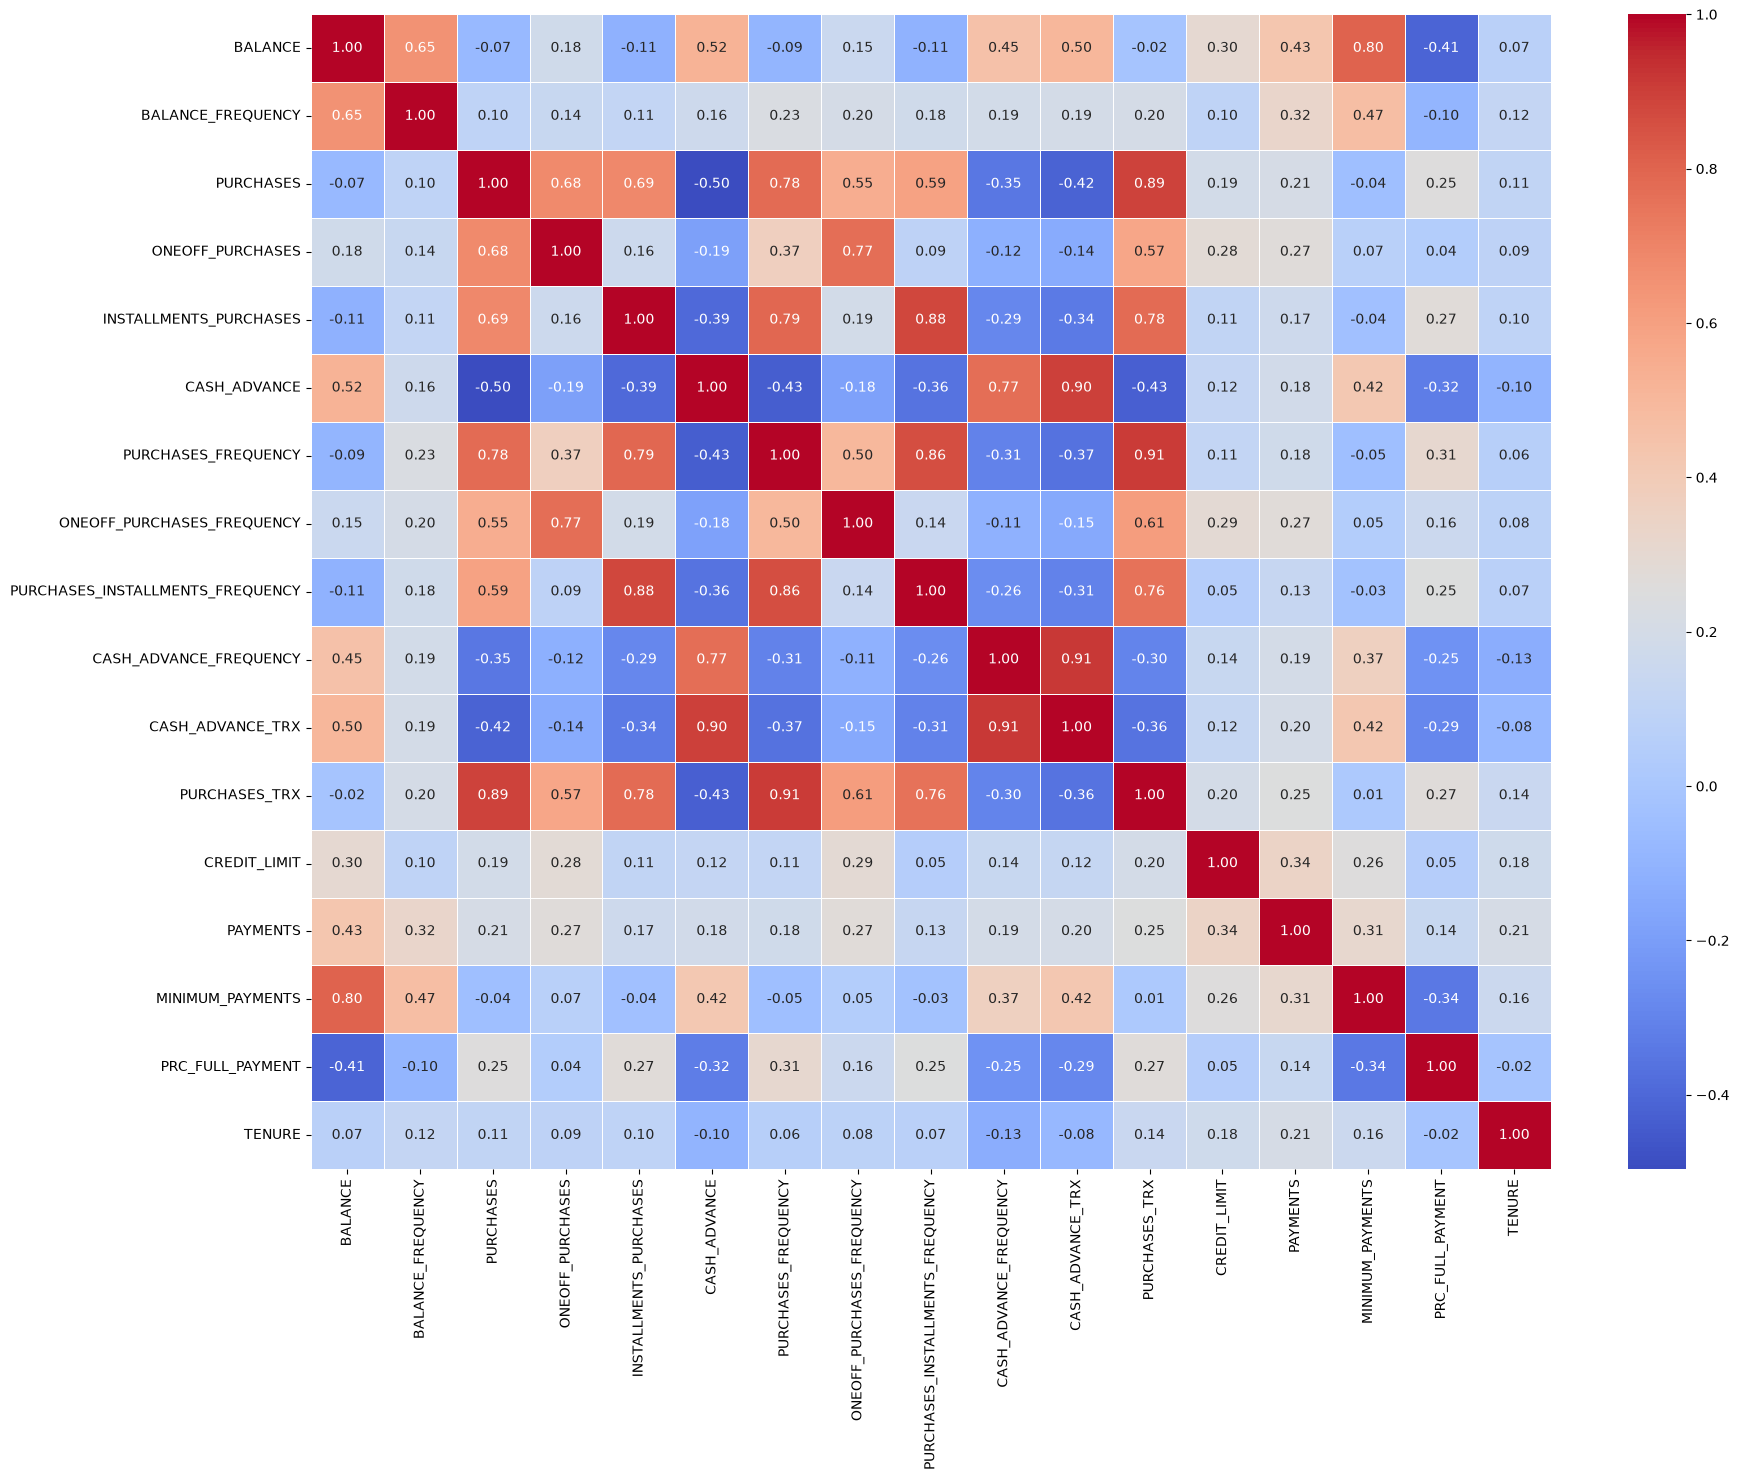

In [10]:
plt.figure(figsize=(20, 15))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.savefig('results/heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

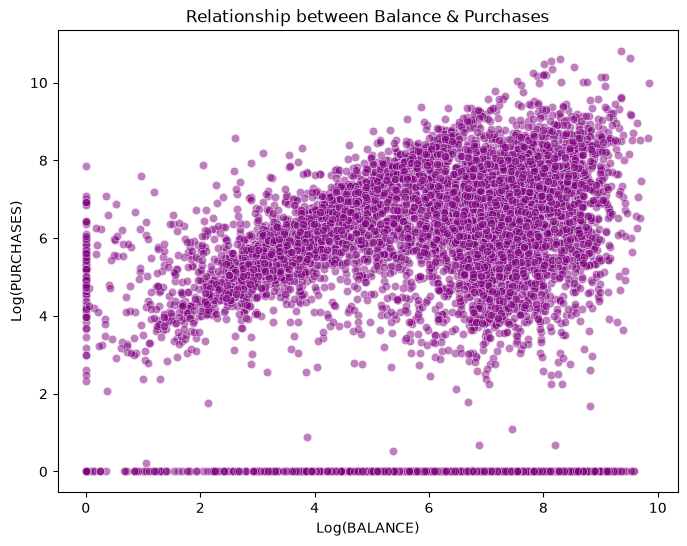

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cleaned, x='BALANCE', y='PURCHASES', alpha=0.5, color='purple')
plt.title('Relationship between Balance & Purchases')
plt.xlabel('Log(BALANCE)')
plt.ylabel('Log(PURCHASES)')
plt.savefig('results/balance_purchase_relationship.png', dpi=200, bbox_inches='tight')
plt.show()

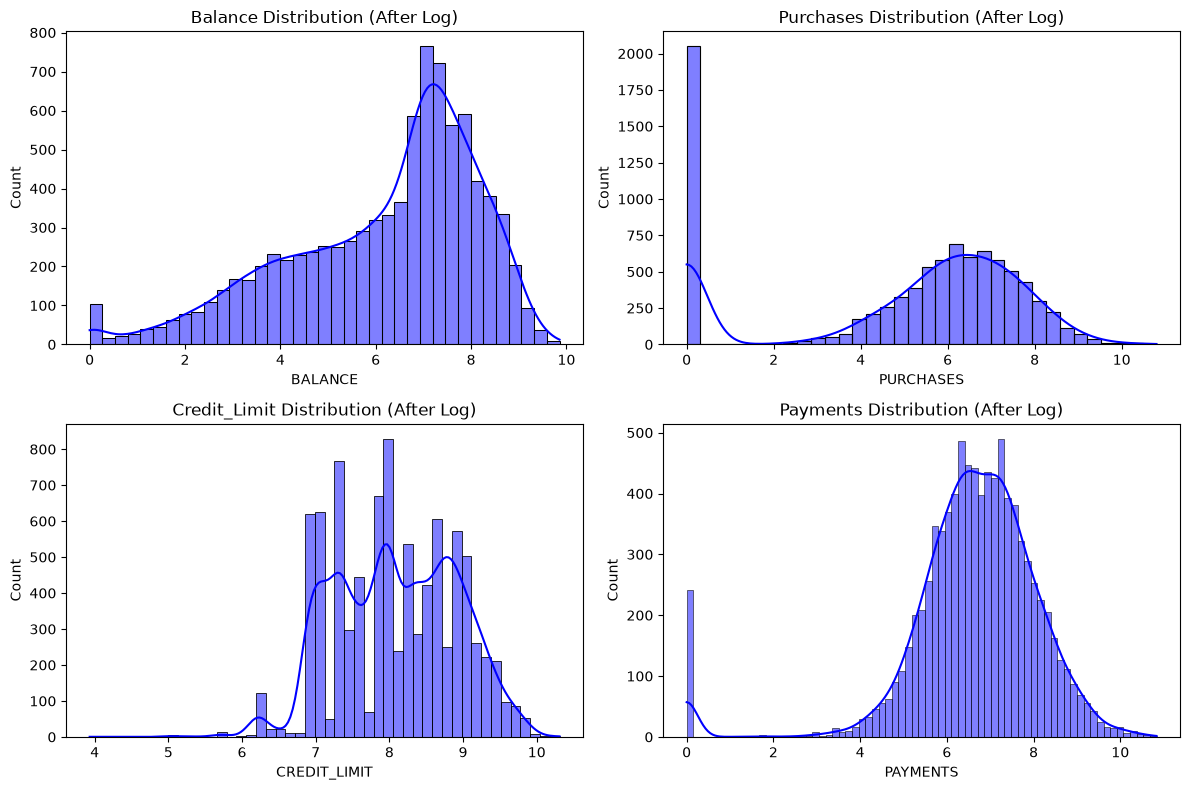

In [12]:
critical_cols = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

plt.figure(figsize=(12, 8))
for i, col in enumerate(critical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_cleaned[col], kde=True, color='blue')
    plt.title(f'{col.title()} Distribution (After Log)')
plt.tight_layout()
plt.savefig('results/distributions.png', dpi=200, bbox_inches='tight')
plt.show()

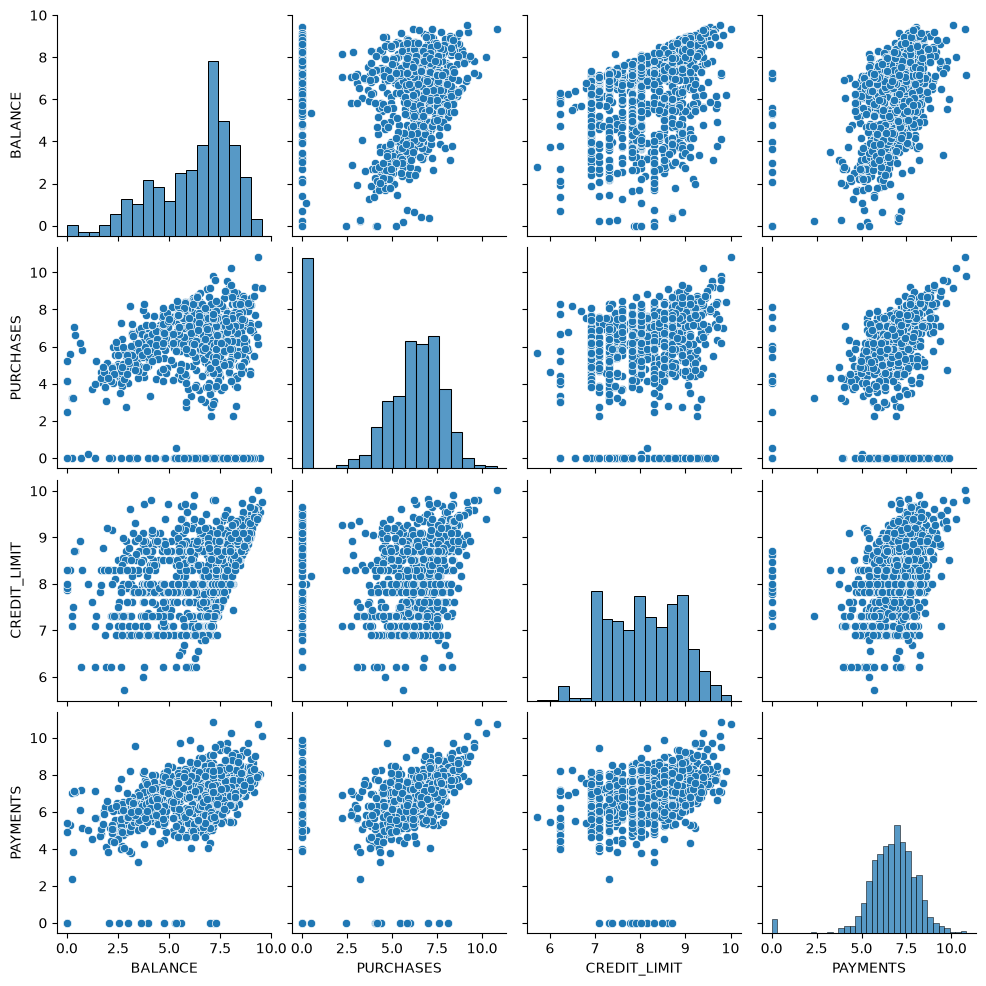

In [13]:
crits = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

sns.pairplot(df_cleaned[crits].sample(1000, random_state=42))
plt.savefig('results/pair_plot.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Model Pipeline

In [14]:
X = df_cleaned

pipe = Pipeline([
    ('scaler', StandardScaler()),
    # 4 clusters mapped to later purposes
    ('model', KMeans(n_clusters=4, init='k-means++',n_init=50, max_iter=300, random_state=42))
])


## 7. Model Training

In [15]:
pipe.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['BALANCE','BALANCE_FREQUENCY','PURCHASES',...,'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT','TENURE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## 8. Evaluation

In [16]:
df_cleaned['label'] = pipe.predict(X)

In [17]:
sil_score = silhouette_score(X, df_cleaned['label'])
db_score = davies_bouldin_score(X, df_cleaned['label'])
ch_score = calinski_harabasz_score(X, df_cleaned['label'])

print(f"Silhouette Score: {sil_score}")
print(f"Davies-Bouldin Score: {db_score}")
print(f"Calinski-Harabasz Score: {ch_score}")

Silhouette Score: 0.25734547176131517
Davies-Bouldin Score: 1.5099309372921457
Calinski-Harabasz Score: 3204.815813117658


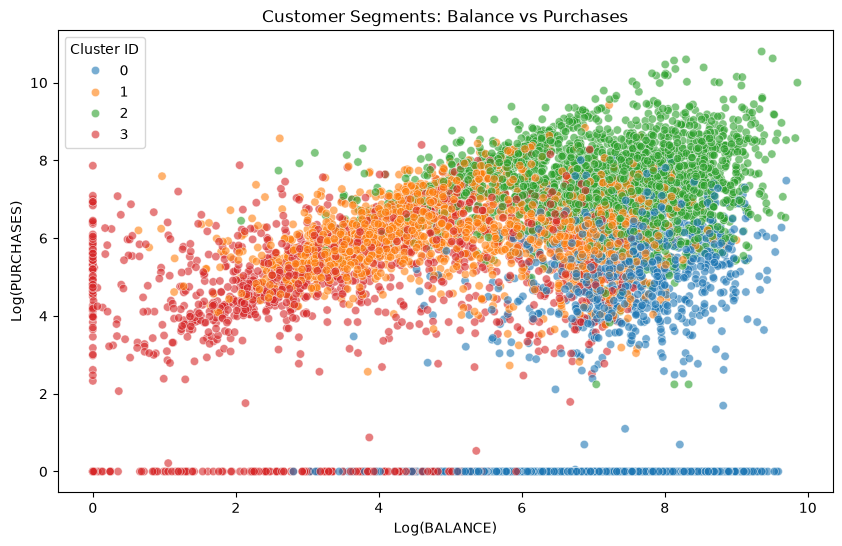

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cleaned, 
    x='BALANCE', 
    y='PURCHASES', 
    hue='label', 
    palette='tab10', 
    alpha=0.6
)
plt.title('Customer Segments: Balance vs Purchases')
plt.xlabel('Log(BALANCE)')
plt.ylabel('Log(PURCHASES)')
plt.legend(title='Cluster ID')
plt.savefig('results/scatter.png', dpi=200, bbox_inches='tight')
plt.show()

In [19]:
print(df_cleaned.groupby('label')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']].mean())

        BALANCE  PURCHASES  CREDIT_LIMIT
label                                   
0      7.404046   1.665343      8.083381
1      5.201940   6.164248      7.727994
2      7.075894   7.419201      8.531628
3      3.675067   4.804515      7.866218


In [20]:
ordered_clusters = df_cleaned.groupby('label')['BALANCE'].mean().sort_values().index

ordered_names = ['Budget Users', 'Active Regulars', 'Top Spenders', 'High Balance Passives']

cluster_names = {raw_label: name for raw_label, name in zip(ordered_clusters, ordered_names)}

df_cleaned['Segment_Name'] = df_cleaned['label'].map(cluster_names)

print(df_cleaned[['BALANCE', 'PURCHASES', 'Segment_Name']].head(7))

    BALANCE  PURCHASES           Segment_Name
0  3.735304   4.568506           Budget Users
1  8.071989   0.000000  High Balance Passives
2  7.822504   6.651791           Top Spenders
3  7.419183   7.313220           Budget Users
4  6.707735   2.833213           Budget Users
5  7.501540   7.196147        Active Regulars
6  6.442955   8.866724           Top Spenders
